# **Importing all the Necessary Libraries**

In [ ]:
# ==============================
# BASIC DATA HANDLING
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING MODULES
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    log_loss,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Styling settings for better visuals
plt.style.use('seaborn-v0_8')
sns.set_style("whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# **Load Both Brownies Universities Datasets**

In [ ]:
# Load VLE dataset (CSV)
vle_df = pd.read_csv('/content/vle_data.csv')

vle_df.head()

,id,vle_logins_per_week,minutes_on_vle_per_week,resources_viewed,video_lectures_watched,forum_posts,quiz_attempts,late_submissions,days_since_last_vle_access
0,200369,19,291,38,5,1,1,0,2
1,200370,15,626,26,3,2,0,0,11
2,200371,17,481,30,5,0,1,0,8
3,200372,18,646,28,3,1,1,1,3
4,200373,18,356,26,3,4,2,0,9


In [ ]:
# Load Personal dataset (Excel)
personal_df = pd.read_excel('/content/personal_data.xlsx')

personal_df.head()

,id,age,gender,ethnicity,first_in_family,disability_flag,commuting_distance_km,accommodation_type,financial_support_flag,attendance_rate,avg_assignment_grade,credits_passed,dropout_risk
0,200369,56,Female,Black,1,0,14,On-campus,0,86.173486,60.821100,30,0
1,200370,46,Male,Black,1,0,11,On-campus,0,65.878952,45.232293,45,1
2,200371,32,Female,White,0,0,9,On-campus,0,96.814505,67.980018,45,0
3,200372,25,Female,Other,0,0,2,Commuting,0,92.083621,91.144084,30,0
4,200373,38,Male,Asian,1,0,2,Off-campus,0,94.637350,46.201419,60,1


# **Merge Datasets (ONLY USING ID COLUMN)**

In [ ]:
# Merge both datasets on ID
df = pd.merge(personal_df, vle_df, on='id', how='inner')

# Check merged dataset
df.head()

,id,age,gender,ethnicity,first_in_family,disability_flag,commuting_distance_km,accommodation_type,financial_support_flag,attendance_rate,avg_assignment_grade,credits_passed,dropout_risk,vle_logins_per_week,minutes_on_vle_per_week,resources_viewed,video_lectures_watched,forum_posts,quiz_attempts,late_submissions,days_since_last_vle_access
0,200369,56,Female,Black,1,0,14,On-campus,0,86.173486,60.821100,30,0,19,291,38,5,1,1,0,2
1,200370,46,Male,Black,1,0,11,On-campus,0,65.878952,45.232293,45,1,15,626,26,3,2,0,0,11
2,200371,32,Female,White,0,0,9,On-campus,0,96.814505,67.980018,45,0,17,481,30,5,0,1,0,8
3,200372,25,Female,Other,0,0,2,Commuting,0,92.083621,91.144084,30,0,18,646,28,3,1,1,1,3
4,200373,38,Male,Asian,1,0,2,Off-campus,0,94.637350,46.201419,60,1,18,356,26,3,4,2,0,9


# **Basic Data Understanding**

In [ ]:
df.shape

(500, 21)

In [ ]:
# Column names
df.columns

Index(['id', 'age', 'gender', 'ethnicity', 'first_in_family', 'disability_flag', 'commuting_distance_km', 'accommodation_type', 'financial_support_flag', 'attendance_rate', 'avg_assignment_grade', 'credits_passed', 'dropout_risk', 'vle_logins_per_week', 'minutes_on_vle_per_week', 'resources_viewed', 'video_lectures_watched', 'forum_posts', 'quiz_attempts', 'late_submissions', 'days_since_last_vle_access'], dtype='object')

In [ ]:
# Missing values check
print(df.isnull().sum())

id                            0
age                           0
gender                        0
ethnicity                     0
first_in_family               0
disability_flag               0
commuting_distance_km         0
accommodation_type            0
financial_support_flag        0
attendance_rate               0
avg_assignment_grade          0
credits_passed                0
dropout_risk                  0
vle_logins_per_week           0
minutes_on_vle_per_week       0
resources_viewed              0
video_lectures_watched        0
forum_posts                   0
quiz_attempts                 0
late_submissions              0
days_since_last_vle_access    0
dtype: int64


In [ ]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          500 non-null    int64  
 1   age                         500 non-null    int64  
 2   gender                      500 non-null    object 
 3   ethnicity                   500 non-null    object 
 4   first_in_family             500 non-null    int64  
 5   disability_flag             500 non-null    int64  
 6   commuting_distance_km       500 non-null    int64  
 7   accommodation_type          500 non-null    object 
 8   financial_support_flag      500 non-null    int64  
 9   attendance_rate             500 non-null    float64
 10  avg_assignment_grade        500 non-null    float64
 11  credits_passed              500 non-null    int64  
 12  dropout_risk                500 non-null    int64  
 13  vle_logins_per_week         500 non

In [ ]:
df.describe()

,id,age,first_in_family,disability_flag,commuting_distance_km,financial_support_flag,attendance_rate,avg_assignment_grade,credits_passed,dropout_risk,vle_logins_per_week,minutes_on_vle_per_week,resources_viewed,video_lectures_watched,forum_posts,quiz_attempts,late_submissions,days_since_last_vle_access
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,200618.500000,39.326000,0.252000,0.094000,9.870000,0.258000,79.562033,58.368938,39.150000,0.470000,14.610000,593.79800,29.184000,4.600000,1.012000,1.854000,0.468000,4.878000
std,144.481833,12.200386,0.434596,0.292121,4.897455,0.437972,14.304973,14.770819,16.406274,0.499599,5.013199,196.32419,10.010122,2.692675,0.951666,1.260103,0.699969,3.549128
min,200369.000000,18.000000,0.000000,0.000000,0.000000,0.000000,22.450167,20.365642,0.000000,0.000000,1.000000,20.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,200493.750000,29.000000,0.000000,0.000000,6.000000,0.000000,70.585628,47.974965,30.000000,0.000000,11.000000,468.75000,23.000000,3.000000,0.000000,1.000000,0.000000,2.000000
50%,200618.500000,41.000000,0.000000,0.000000,10.000000,0.000000,80.114294,58.967274,45.000000,0.000000,14.000000,595.50000,29.000000,4.000000,1.000000,2.000000,0.000000,4.000000
75%,200743.250000,50.000000,1.000000,0.000000,13.000000,1.000000,91.678570,67.648289,45.000000,1.000000,18.000000,729.50000,36.000000,6.000000,2.000000,3.000000,1.000000,7.000000
max,200868.000000,59.000000,1.000000,1.000000,27.000000,1.000000,100.000000,100.000000,60.000000,1.000000,28.000000,1129.00000,56.000000,13.000000,5.000000,5.000000,4.000000,16.000000


# **Dataset Exploration**

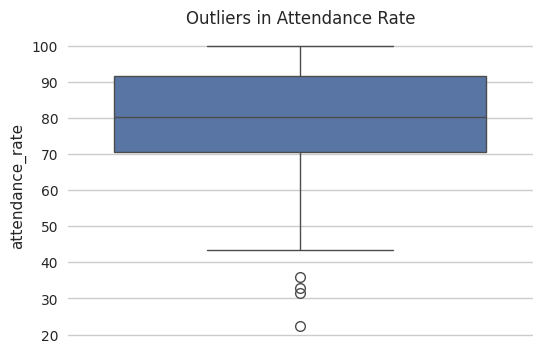

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['attendance_rate'])
plt.title("Outliers in Attendance Rate")
plt.show()

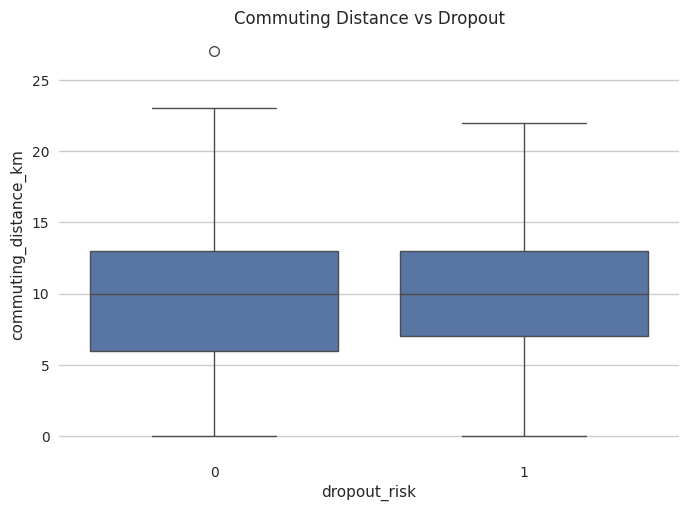

In [ ]:
sns.boxplot(x='dropout_risk', y='commuting_distance_km', data=df)
plt.title("Commuting Distance vs Dropout")
plt.show()

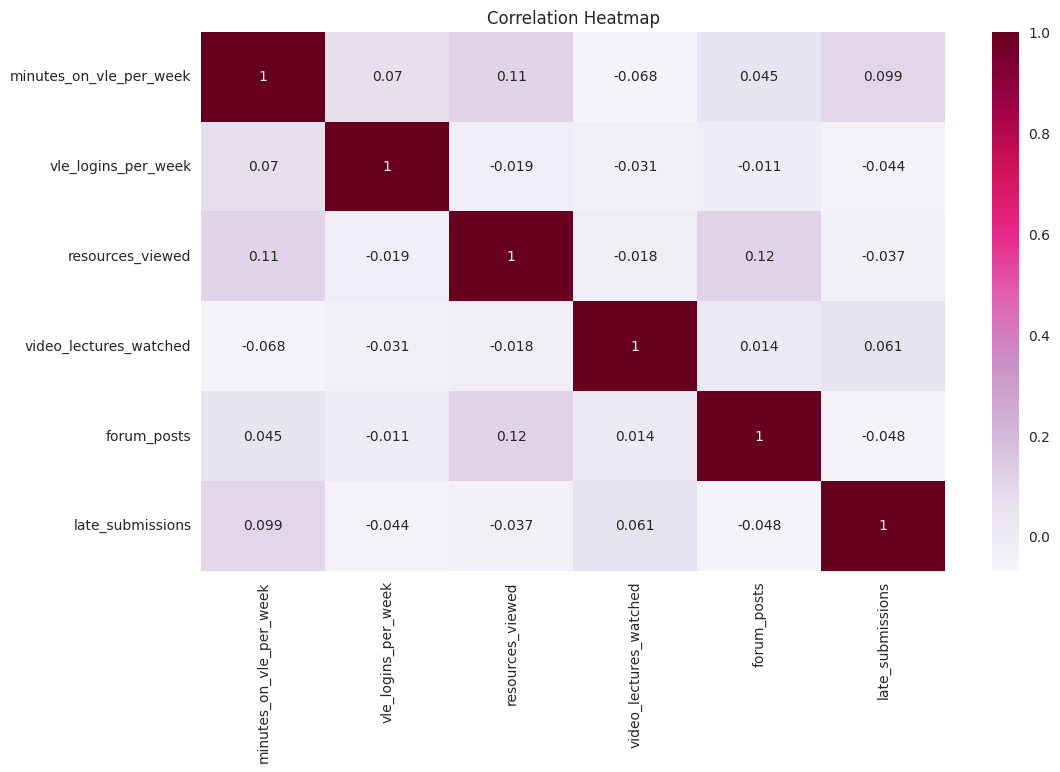

In [ ]:
# Correlation heatmap

numeric_cols = ['minutes_on_vle_per_week', 'vle_logins_per_week', 'resources_viewed', 'video_lectures_watched', 'forum_posts']

plt.figure(figsize=(12,7))
sns.heatmap(df[numeric_cols + ['late_submissions']].corr(), annot=True, cmap='PuRd')
plt.title("Correlation Heatmap")
plt.show()

# **Descriptive Statistical Analysis**

## **Dropout Data Divided by Gender**

In [ ]:
# Replace abbreviations with full labels
df['gender'] = df['gender'].replace({
    'F': 'Female',
    'M': 'Male'
})

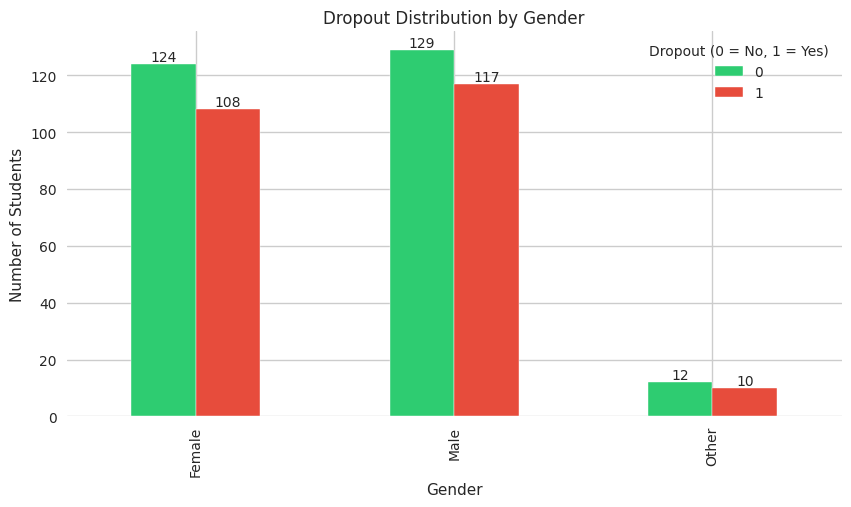

In [ ]:
# Group data
gender_dropout = df.groupby(['gender', 'dropout_risk']).size().unstack()

# Plot
gender_dropout.plot(
    kind='bar',
    figsize=(10,5),
    color=['#2ecc71', '#e74c3c']  # green + red
)

plt.title("Dropout Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

# Data labels
for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.legend(title="Dropout (0 = No, 1 = Yes)")
plt.show()

## **Average Age of Students**

In [ ]:
avg_age = df['age'].mean()
print("Average Age of Students:", round(avg_age,2))

Average Age of Students: 39.33


## **Average Minutes on VLE per Week**

In [ ]:
avg_vle = df['minutes_on_vle_per_week'].mean()
print("Average Minutes on VLE per Week:", round(avg_vle,2))

Average Minutes on VLE per Week: 593.8


## **Distribution of Attendance Rate**

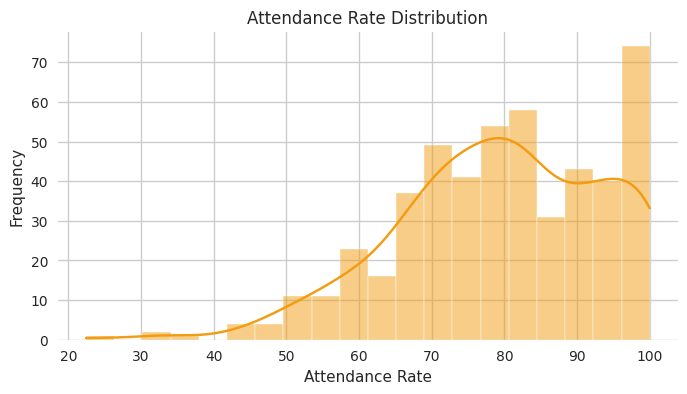

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['attendance_rate'], bins=20, color='#f39c12', kde=True)

plt.title("Attendance Rate Distribution")
plt.xlabel("Attendance Rate")
plt.ylabel("Frequency")

plt.show()

## **Distribution of Assignment Grade**

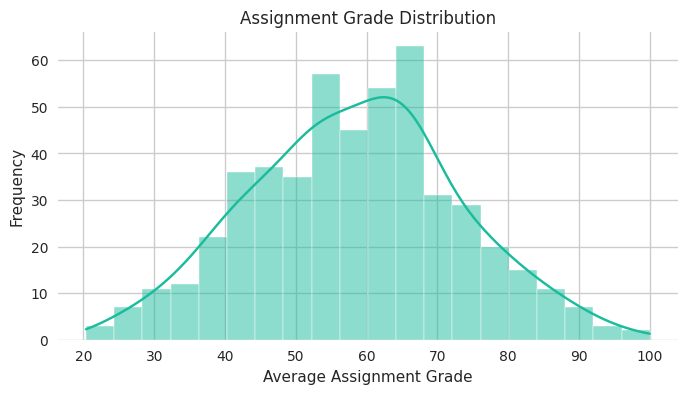

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['avg_assignment_grade'], bins=20, color='#1abc9c', kde=True)

plt.title("Assignment Grade Distribution")
plt.xlabel("Average Assignment Grade")
plt.ylabel("Frequency")

plt.show()

## **Attendance Rate by Accommodation Type**

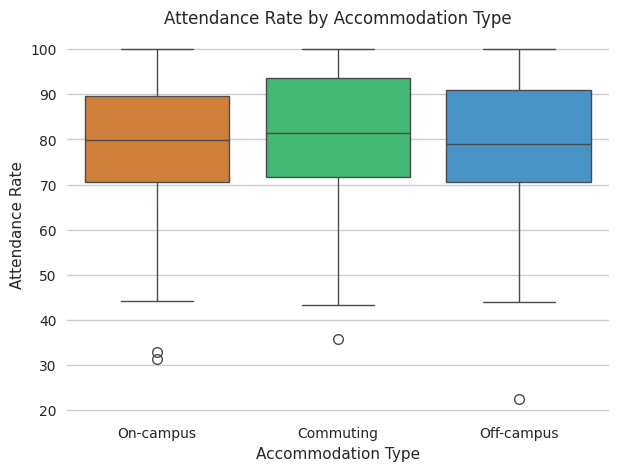

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='accommodation_type',
    y='attendance_rate',
    data=df,
    palette=['#e67e22', '#2ecc71', '#3498db']
)

plt.title("Attendance Rate by Accommodation Type")
plt.xlabel("Accommodation Type")
plt.ylabel("Attendance Rate")

plt.show()

## **Relationship Between Commuting Distance and Dropout**

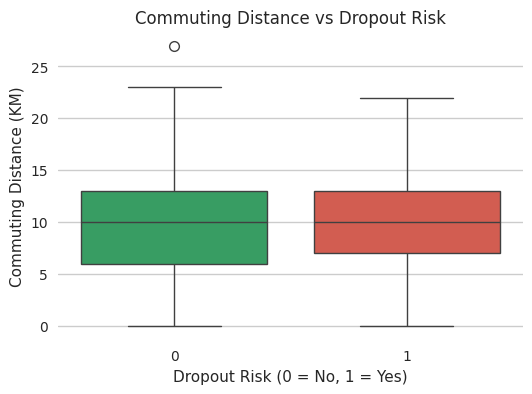

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='dropout_risk',
    y='commuting_distance_km',
    data=df,
    palette=['#27ae60', '#e74c3c']
)

plt.title("Commuting Distance vs Dropout Risk")
plt.xlabel("Dropout Risk (0 = No, 1 = Yes)")
plt.ylabel("Commuting Distance (KM)")

plt.show()

## **Dropout Numbers by Accommodation Type**

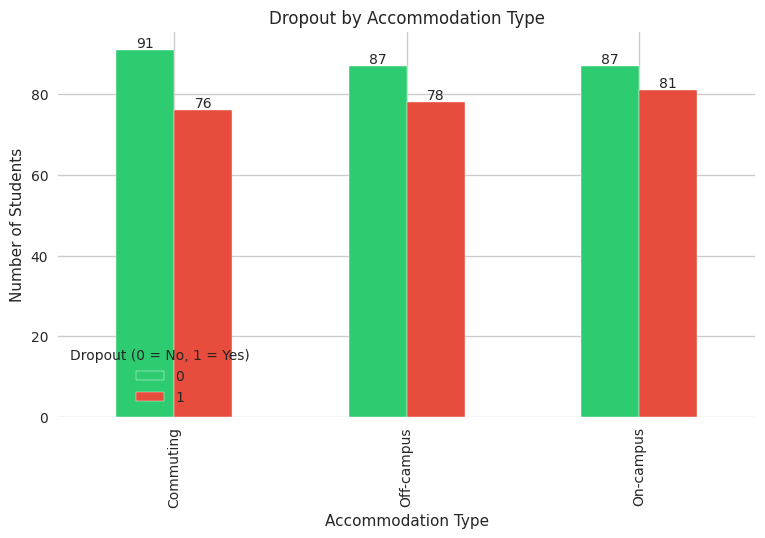

In [ ]:
acc_dropout = df.groupby(['accommodation_type', 'dropout_risk']).size().unstack()

acc_dropout.plot(
    kind='bar',
    figsize=(9,5),
    color=['#2ecc71', '#e74c3c']
)

plt.title("Dropout by Accommodation Type")
plt.xlabel("Accommodation Type")
plt.ylabel("Number of Students")

# Data labels
for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.legend(title="Dropout (0 = No, 1 = Yes)")
plt.show()

## **Relationship Between Assignment Score and Late Submissions**

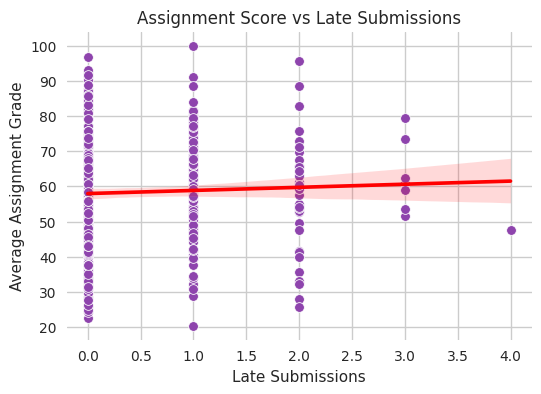

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='late_submissions',
    y='avg_assignment_grade',
    data=df,
    color='#8e44ad'
)

sns.regplot(
    x='late_submissions',
    y='avg_assignment_grade',
    data=df,
    scatter=False,
    color='red'
)

plt.title("Assignment Score vs Late Submissions")
plt.xlabel("Late Submissions")
plt.ylabel("Average Assignment Grade")

plt.show()

# **DATA PREPARATION (FEATURE + TARGET SPLIT)**

In [ ]:
# Drop ID column (not useful for ML)
df_model = df.drop('id', axis=1)

# Convert categorical variables using encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Define features (X) and target (y)
X = df_model.drop('dropout_risk', axis=1)
y = df_model['dropout_risk']

## **TRAIN / TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **FEATURE SCALING**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **MODEL 1 — ADABOOST CLASSIFIER**

In [ ]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:,1]

In [ ]:
ada_acc = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 0.94


In [ ]:
print("AdaBoost Classification Report")
print(classification_report(y_test, y_pred_ada))

AdaBoost Classification Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        53
           1       0.96      0.91      0.93        47

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [ ]:
ada_logloss = log_loss(y_test, y_prob_ada)
print("AdaBoost Log Loss:", ada_logloss)

AdaBoost Log Loss: 0.541711646159124


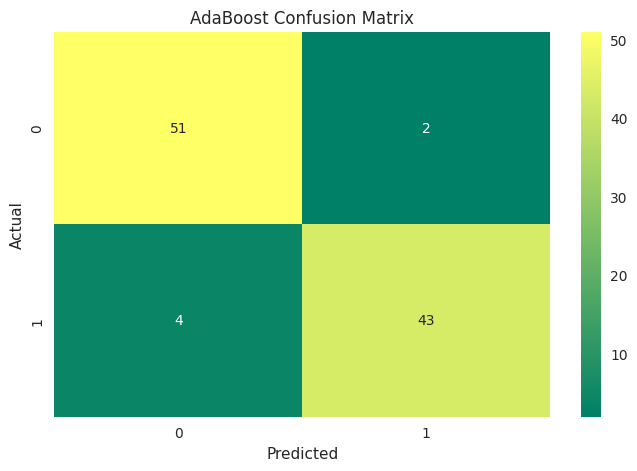

In [ ]:
cm_ada = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(8,5))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='summer')

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## **MODEL 2 — NAIVE BAYES**

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
nb_acc = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.81


In [ ]:
print("Naive Bayes Classification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        53
           1       0.80      0.79      0.80        47

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



In [ ]:
nb_logloss = log_loss(y_test, y_prob_nb)
print("Naive Bayes Log Loss:", nb_logloss)

Naive Bayes Log Loss: 0.4215772353742121


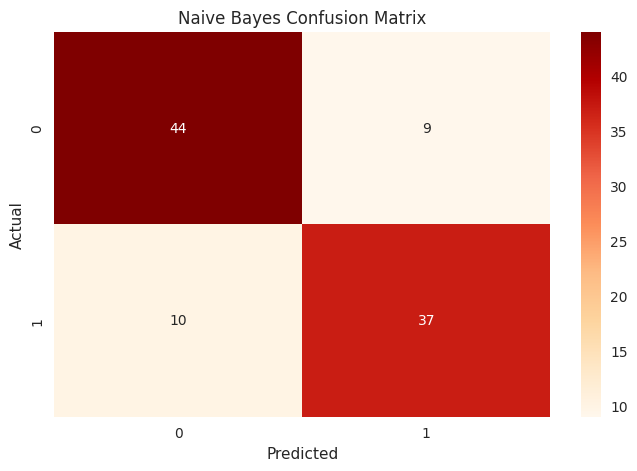

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='OrRd')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["AdaBoost", "Naive Bayes"],
    "Accuracy": [ada_acc, nb_acc],
    "Log Loss": [ada_logloss, nb_logloss]
})

print(comparison)

         Model  Accuracy  Log Loss
0     AdaBoost      0.94  0.541712
1  Naive Bayes      0.81  0.421577
